# Credit Risk Scorecard 

**Autor:** Mathias Alejandro Gómez Chan

**Email:** [mathias70473@gmail.com](mailto:mathias70473@gmail.com)

**GitHub:** [GitHub/Mathias-ds](https://github.com/Mathias70473)

**Date:** April 2026

---


## Business Context
Credit scoring is the process of assigning a numerical value to a loan applicant 
that reflects their likelihood of default. This project builds a production-style 
credit scorecard using the German Credit Dataset, following industry-standard 
methodology used by banks and fintechs.

## Dataset
- **Source:** UCI Machine Learning Repository — German Credit Data
- **Size:** 1,000 observations, 20 features, 1 target variable
- **Target:** `kredit` — 1 = good credit (no default), 0 = bad credit (default)
- **Class balance:** 70% good, 30% bad

### Production context
In a real banking environment, this data would live in a relational database. 
A credit analyst would extract it using SQL queries joining multiple tables like 
loan origination, customer demographics, transaction history. The flat CSV 
used here simulates that extracted dataset.

The German Credit Dataset represents a realistic sample of a real life data 
compilation; with a comprehensive list of 20 features that can contribute to describe
a good linear relation with the Target Variable and, helps as an excellent exercise for
data science modeling.

## Variable Dictionary

| Variable | Name | Type |
|---|---|---|
| laufkont | Checking account status | Categorical |
| laufzeit | Duration (months) | Continuous |
| moral | Credit history | Categorical |
| verw | Purpose | Categorical |
| hoehe | Loan amount | Continuous |
| sparkont | Savings account | Categorical |
| beszeit | Employment duration | Categorical |
| rate | Installment rate | Categorical |
| famges | Personal status / sex | Categorical |
| buerge | Guarantors | Categorical |
| wohnzeit | Residence duration | Categorical |
| verm | Property | Categorical |
| alter | Age | Continuous |
| weitkred | Other installments | Categorical |
| wohn | Housing | Categorical |
| bishkred | Existing credits | Categorical |
| beruf | Job | Categorical |
| pers | Dependents | Categorical |
| telef | Telephone | Categorical |
| gastarb | Foreign worker | Categorical |
| kredit | Target — credit outcome | Target |




> For full category definitions and dataset documentation, refer to the 
> [UCI Machine Learning Repository — German Credit Data (Kaggle)](https://www.kaggle.com/datasets/varunchawla30/german-credit-data).

# 1. Exploratory Data Analysis (EDA)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/german_credit_data.csv')

## 1.1 Data Loading and Quality Check

Given the diverse information provided by the dataset, three important details were evaluated:
- Missing Values: Evaluate if the dataset has null values and, how many.
- Data Types: Which types of data are encoded in the dataset.
- Shape: Finally the shape that show us the number of rows and, columns.

**Findings:** After careful evaluation the datasets did not present null values and, all information is encoded in an integer data type, which makes it easier to evaluate in the case of categorical variables previously shown in the variable dictionary.

Finally the shape of the dataset corresponds to 21 columns which include the 20 features and, one target variable and, 1,000 observations.

In [2]:
# =================================================================================================================================================================
# 1.1 Data Loading and, Quality Check
# =================================================================================================================================================================

print('='* 70)
print('DATA QUALITY EVALUATION')
print('='* 70)

## Missing Values in the dataset:
print('The number of missing values per variable is: \n', df.isna().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print('='* 70)

## Data Types:

print('The Data Types in the dataset: \n', df.dtypes)
print('='*70)

print('The Data Shape in the dataset:', df.shape)
print('='*70)

DATA QUALITY EVALUATION
The number of missing values per variable is: 
 laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64

Total missing values: 0
The Data Types in the dataset: 
 laufkont    int64
laufzeit    int64
moral       int64
verw        int64
hoehe       int64
sparkont    int64
beszeit     int64
rate        int64
famges      int64
buerge      int64
wohnzeit    int64
verm        int64
alter       int64
weitkred    int64
wohn        int64
bishkred    int64
beruf       int64
pers        int64
telef       int64
gastarb     int64
kredit      int64
dtype: object
The Data Shape in the dataset: (1000, 21)


## 1.2 Target Variable Distribution

Once we determined a basic data description of the dataset as a whole, it was important to assess the target variable distribution and, balance between Good and, Bad customer with a loan.

**Findings**: After the count evaluation, I found a 70/30 distribution among customers credit, meaning that: 70% of the data corresponds to Good Credits and, 30% to bad credits. Which shows a big imbalance in the dataset, this is excellent news in the business standpoint but, it requires careful evaluation for the model.

TARGET VARIABLE DISTRIBUTION
The count for Good and, Bad credits in the dataset: 
 kredit
1    700
0    300
Name: count, dtype: int64

The proportion for Good and, Bad credits in the dataset: 
 kredit
1    0.7
0    0.3
Name: proportion, dtype: float64


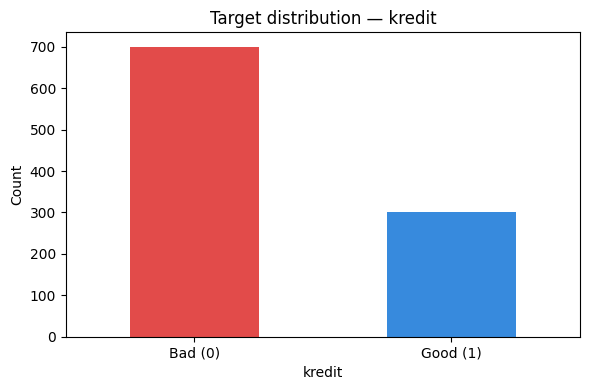

In [3]:
# =================================================================================================================================================================
# 1.2 Target Variable Distribution
# =================================================================================================================================================================

print('='* 70)
print('TARGET VARIABLE DISTRIBUTION')
print('='* 70)

# Target distribution
print('The count for Good and, Bad credits in the dataset: \n',df['kredit'].value_counts())
print('\nThe proportion for Good and, Bad credits in the dataset: \n', df['kredit'].value_counts(normalize=True).round(3))

print('='*70)

fig, ax = plt.subplots(figsize=(6, 4))
df['kredit'].value_counts().plot(kind='bar', ax=ax, color=['#E24B4A', '#378ADD'])
ax.set_xticklabels(['Bad (0)', 'Good (1)'], rotation=0)
ax.set_title('Target distribution — kredit')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/figures/target_distribution.png', dpi=150)
plt.show()

## 1.3 Continuous Variable Distributions
The dataset contains three truly continuous variables:
- Duration 
- Amount
- Age

This distinction matters for the WoE pipeline; continuous variables require 
quantile binning (pd.qcut) to create meaningful groups, while categorical 
variables use their existing codes directly as bins.

### Key findings
- **Duration:** Spikes at 12, 24, 36 months indicate contract terms. 
  Quantile binning will handle this naturally but expect unequal bin sizes 
  due to duplicate values at round numbers.

- **Amount:** Heavy right skew. Equal-width 
  bins would be useless here, most observations would fall in the first bin. 
  Quantile binning ensures each bin has enough observations for stable WoE estimates.

- **Age:** Moderate right skew, concentrated 20–40. Sparse data past 60 
  means the upper tail bins will be thin — watch for unstable WoE values there.


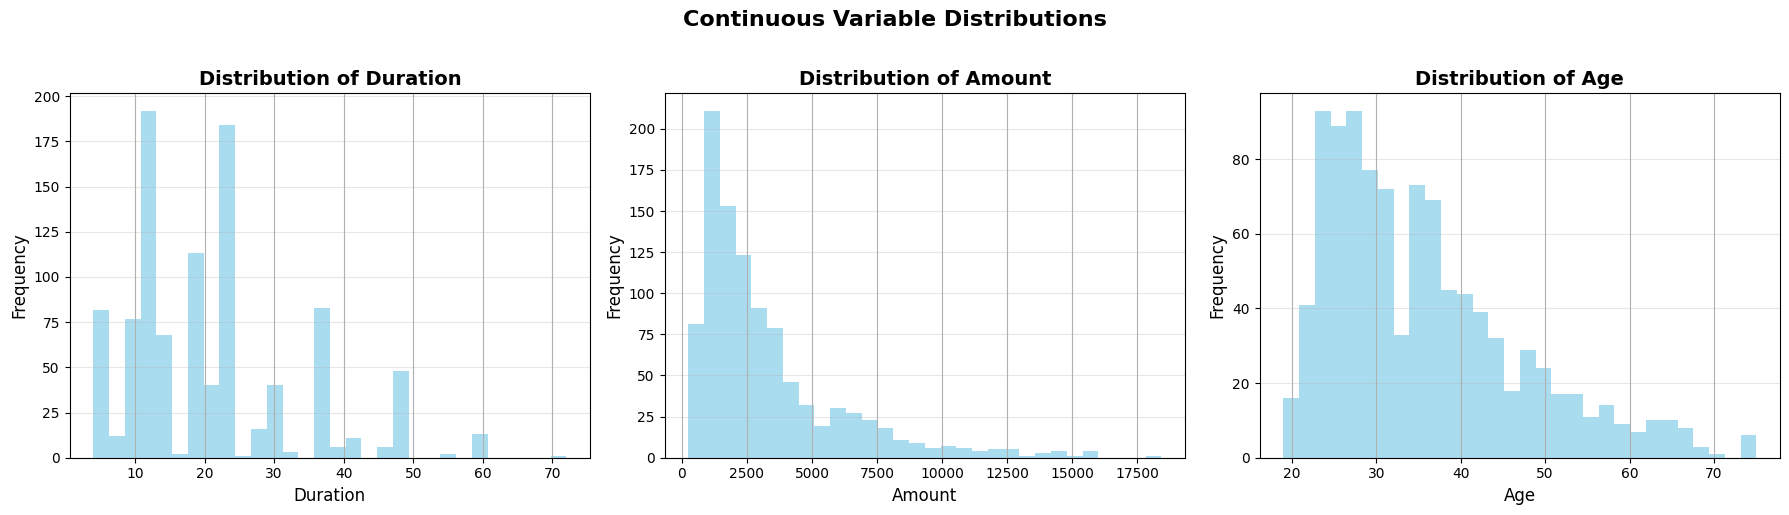

In [4]:
# =================================================================================================================================================================
# 1.3 Continuous Variable Distribution Visualization
# =================================================================================================================================================================

print('='* 70)
#continuous variable
continuous = ['laufzeit', 'hoehe', 'alter']
continuous_map = {'laufzeit': 'Duration', 'hoehe': 'Amount', 'alter': 'Age'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, continuous_map.items()):
    df[col].hist(bins=30, color='skyblue', alpha=0.7, ax=ax)
    ax.set_title(f'Distribution of {label}', fontsize=14, fontweight='bold')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Continuous Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

 ## 1.4 Categorical Variable Distributions
 
The dataset contains 17 categorical variables encoded as integers. 
All 17 were plotted and reviewed visually before computing WoE/IV.

Three variables showed the clearest separation between good and bad 
customers at this stage:

- **Checking account status (laufkont):** Strong monotonic pattern:
  category 1 has 50% good rate, category 4 has 88% good rate
- **Credit history (moral):** Clear risk gradient: categories 0 and 1 
  significantly riskier than categories 3 and 4
- **Savings account (sparkont):** Higher savings categories associated 
  with lower default rates

The remaining variables showed weaker or less consistent patterns. 
All variables were carried forward to WoE/IV computation in notebook 02, 
where Information Value was used to make the final feature selection decision.

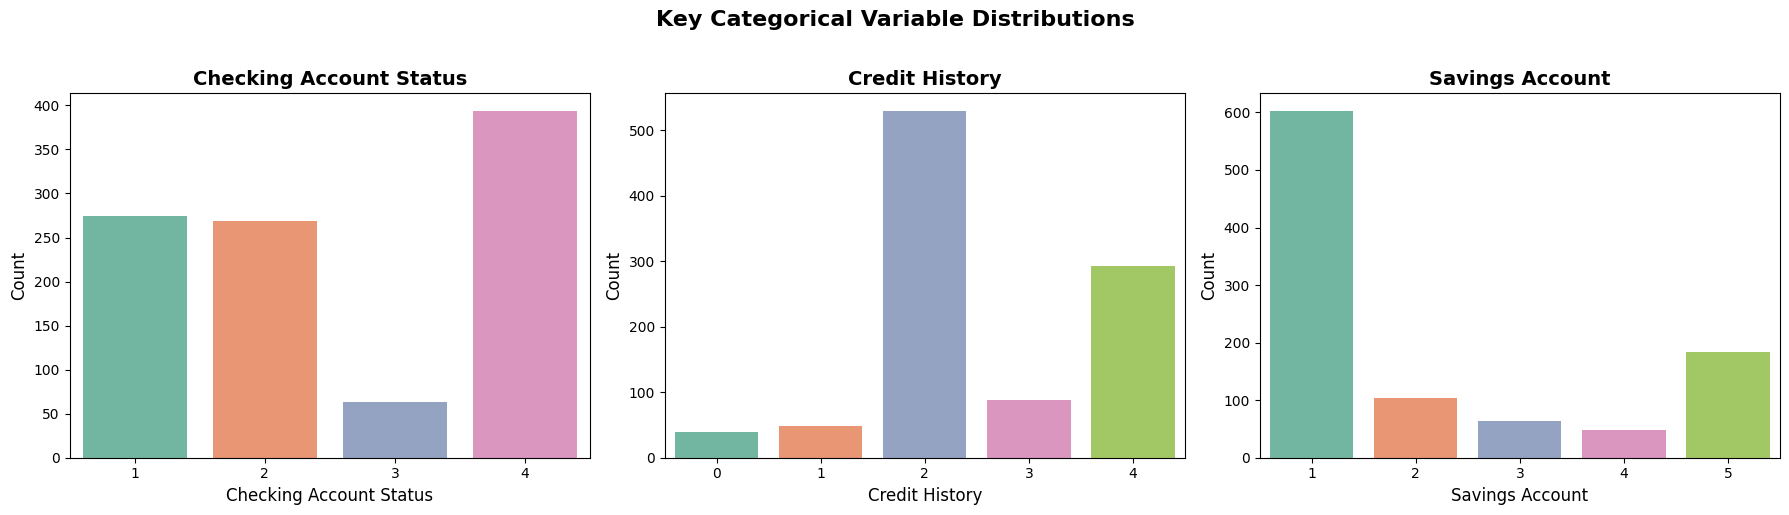

In [5]:
# =================================================================================================================================================================
# 1.4 Categorical Variable Distribution Visualization
# =================================================================================================================================================================

key_map = {'laufkont': 'Checking Account Status', 'moral': 'Credit History', 'sparkont': 'Savings Account'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, label) in zip(axes, key_map.items()):
    sns.countplot(data=df, x=col, hue=col, palette='Set2', ax=ax, legend=False)
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

plt.suptitle('Key Categorical Variable Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/key_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Relationship with Target Variable

To preview predictive power before modeling, we analyzed how each variable 
relates to the target directly.

### Continuous variables
Boxplots split by `kredit` reveal three consistent patterns:

- **Duration:** Bad loans have a notably higher median (~24 months vs ~18 months). 
  Longer loans carry higher risk.
- **Amount:** Similar medians across groups, but bad loans show more extreme 
  high-amount outliers. Large loans are riskier at the tail.
- **Age:** Good loans skew slightly older. Younger borrowers default more frequently.

### Categorical variables
Default rate per category was plotted for checking account status, credit 
history, and savings account. The three strongest visual candidates from 
Section 4 were plotted and, the findings are the following:

- **Checking account status:** Most discriminating variable visually — 
  clear monotonic increase in good rate from category 1 to 4
- **Credit history:** Categories 0 and 1 well below the overall mean good 
  rate of 70% 
- **Savings account:** Categories 3, 4, and 5 above the mean, which means higher 
  savings associated with lower risk

These visual patterns were confirmed quantitatively in notebook 02 through 
Information Value. Variables that showed separation here consistently 
ranked as Medium or Strong predictors.

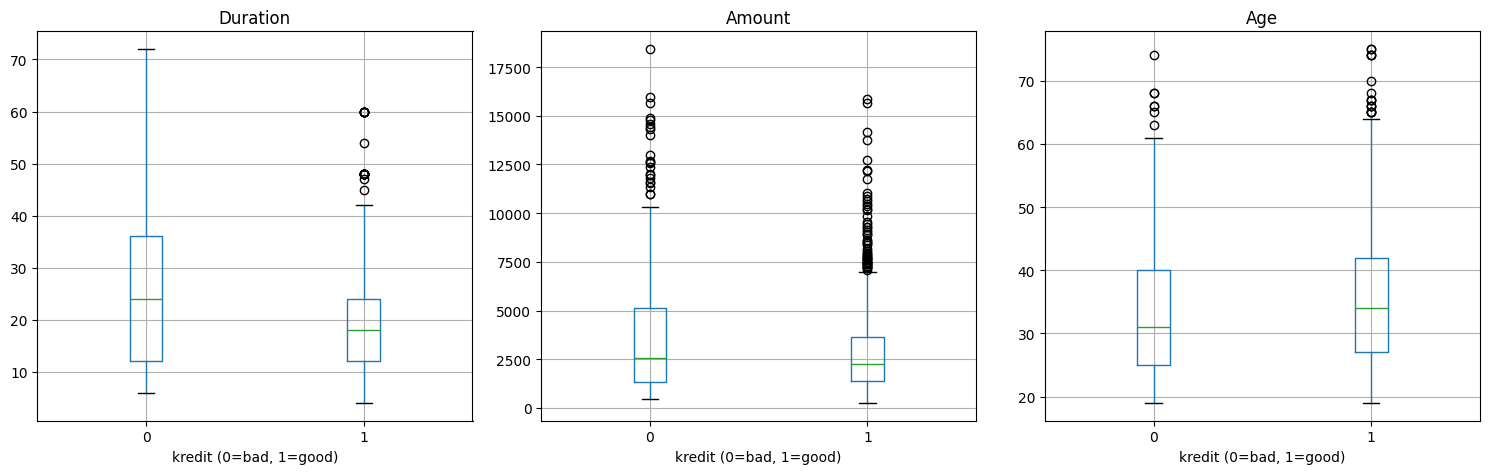

In [6]:
# =================================================================================================================================================================
# 1.5 Continuous Variable with Target Variable Visualization
# =================================================================================================================================================================


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, continuous):
    df.boxplot(column=var, by='kredit', ax=ax)
    ax.set_title(continuous_map[var])
    ax.set_xlabel('kredit (0=bad, 1=good)')
plt.suptitle('')
plt.tight_layout()
plt.show()

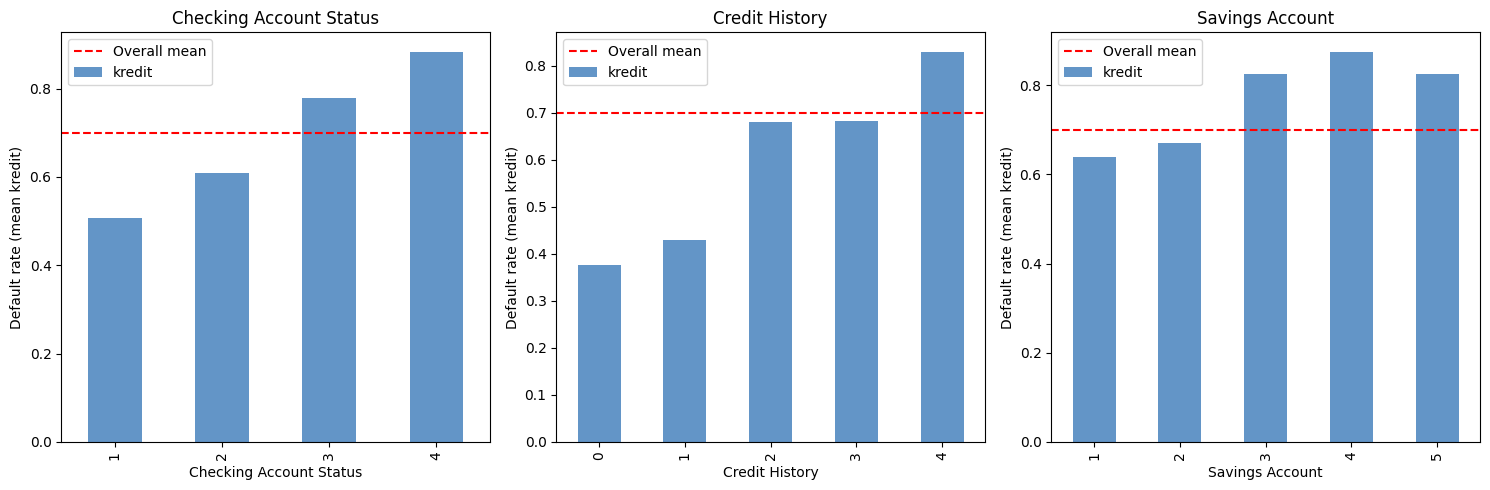

In [7]:
# =================================================================================================================================================================
# 1.5 Categorical Variable with Target Variable Visualization
# =================================================================================================================================================================

key_map = {'laufkont': 'Checking Account Status', 'moral': 'Credit History', 'sparkont': 'Savings Account'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (var, label) in zip(axes, key_map.items()):
    default_rate = df.groupby(var)['kredit'].mean()
    default_rate.plot(kind='bar', ax=ax, color="#6395C7")
    ax.set_title(label)
    ax.set_ylabel('Default rate (mean kredit)')
    ax.set_xlabel(label)
    ax.axhline(df['kredit'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.legend()

plt.tight_layout()
plt.show()

# 2. Weight of Evidence and Information Value

## What is Weight of Evidence?

    WoE = ln(% of Events in bin / % of Non-Events in bin)
    Where Events = bad loans, Non-Events = good loans

The WoE is a transformation of the scale of a feature variable, the variables are discretized into bins and, later transformed in a log-odds scale which is perfectly compatible with a LogisticRegression. In the case of for example a WoE = 0, it means that the WoE in an specific bin does not differ from the overall event rate, in that case the specific bin does not provide discriminative information.

## What is Information Value?
           IV = Σ (% Events - % Non-Events) × WoE
### IV interpretation table
| IV Range | Predictive Power |
|---|---|
| < 0.02 | Useless |
| 0.02 – 0.10 | Weak |
| 0.10 – 0.30 | Medium |
| 0.30 – 0.50 | Strong |
| > 0.50 | Very strong (suspicious) |

The IV, can be better described as a statistic that evaluates the predictive power of a selected feature in a model, following the interpretation table we determine weather a feature should be included in the model. It should be noted that a very high IV value can raise suspicion, as it might indicate data leakage rather than predictive power.

In [8]:
# =================================================================================================================================================================
# Feature Maps
# =================================================================================================================================================================

# Continuous variable
continuous = ['laufzeit', 'hoehe', 'alter']
continuous_map={'laufzeit':'Duration', 'hoehe':'Amount', 'alter':'Age'}

# Categorical
categorical = ['laufkont', 'moral', 'verw', 'sparkont', 'beszeit',
               'rate', 'famges', 'buerge', 'wohnzeit', 'verm',
               'weitkred', 'wohn', 'bishkred', 'beruf', 'pers',
               'telef', 'gastarb']


categorical_map = {
    'laufkont': 'Checking account status',
    'moral': 'Credit history',
    'verw': 'Purpose',
    'sparkont': 'Savings account',
    'beszeit': 'Employment duration',
    'rate': 'Installment rate',
    'famges': 'Personal status_sex',
    'buerge': 'Guarantors',
    'wohnzeit': 'Residence duration',
    'verm': 'Property',
    'weitkred': 'Other installments',
    'wohn': 'Housing',
    'bishkred': 'Existing credits',
    'beruf': 'Job',
    'pers': 'Dependents',
    'telef': 'Telephone',
    'gastarb': 'Foreign worker'
}

target = 'kredit'

## 2.1 Binning Strategy and, WoE/IV Functions

Continuous variables are binned using `pd.qcut` to ensure each bin has enough observations for stable WoE estimates, the use of `pd.cut` was discarted given the skewed distributions observed in Duration and, Amount, equal-width bins would allocate the majority of values in an specific bin. Categorical Variables use their existing integer as bins.

Both functions follow the same logic:
1. Bin the variable
2. Count good and, bad per bin
3. Compute WoE per bin
4. Sum to IV for each variable

Results are stored in a dictionary keyed by the variable name.

> **Note on WoE convention:** This project uses WoE = ln(% Bad / % Good), 
> where higher WoE indicates higher risk. Signs are reversed from the 
> standard industry convention but interpretation is equivalent.


In [9]:
# =================================================================================================================================================================
# WoE/IV Functions for Continuous and, Categorical variables
# =================================================================================================================================================================

# WoE/IV for continuous variables
def woe_fun(df, map):
    results = {}
    for a, b in map.items():
        t = pd.DataFrame({'bin': pd.qcut(df[a], q=10, duplicates='drop'), 'kredit': df['kredit']})
        woe = t.groupby('bin', observed=True)['kredit'].agg(['count','sum']).reset_index()
        woe.columns = ['bin','total','good']
        woe['bad'] = woe['total'] - woe['good']
        woe['pct_good'] = woe['good'] / woe['good'].sum()
        woe['pct_bad'] = woe['bad']  / woe['bad'].sum()
        woe['WoE'] = np.log(woe['pct_bad'] / woe['pct_good'])
        woe['iv_bin'] = (woe['pct_bad'] - woe['pct_good']) * woe['WoE']
        results[a] = woe
        print(f"\n{b} ({a}) — IV: {woe['iv_bin'].sum():.4f}\n{woe.to_string(index=False)}")
    return results

# WoE/IV for categorical variables
def woe_fun_cat(df, map):
    results = {}
    for a, b in map.items():
        t = pd.DataFrame({'bin': df[a], 'kredit': df['kredit']})
        woe = t.groupby('bin', observed=True)['kredit'].agg(['count','sum']).reset_index()
        woe.columns = ['bin','total','good']
        woe['bad'] = woe['total'] - woe['good']
        woe['pct_good'] = woe['good'] / woe['good'].sum()
        woe['pct_bad'] = woe['bad']  / woe['bad'].sum()
        woe['WoE'] = np.log(woe['pct_bad'] / woe['pct_good'])
        woe['iv_bin'] = (woe['pct_bad'] - woe['pct_good']) * woe['WoE']
        results[a] = woe
        print(f"\n{b} ({a}) — IV: {woe['iv_bin'].sum():.4f}\n{woe.to_string(index=False)}")
    return results

## 2.2 Continuous Variables — WoE/IV Results

WoE and IV were computed for the three continuous variables using quantile binning 
with `q=10`, but adding `duplicates='drop'` that creates 8 quantiles. All three show a consistent directional pattern — risk increases 
with longer duration, higher loan amounts, and younger age.

| Variable | IV | Predictive Power |
|---|---|---|
| Duration (laufzeit) | 0.2465 | Medium |
| Amount (hoehe) | 0.1138 | Medium |
| Age (alter) | 0.1048 | Medium |

**Duration:** shows a clear monotonic pattern. WoE moves from negative 
(short loans, lower risk) to positive (long loans, higher risk) as duration 
increases. This is the strongest continuous predictor.

**Amount:** shows a weaker signal, the upper tail (loans above 7,000 DM) shows a clear positive WoE.
Large loans carry higher default risk.

**Age:** shows that younger borrowers (under 26) are riskier, while middle-aged 
borrowers (33–44) are safer. The signal is moderate and less consistent than Duration.

In [10]:
# =================================================================================================================================================================
# WoE/IV  for Continuous feature
# =================================================================================================================================================================

continuous_woe = woe_fun(df, continuous_map)


Duration (laufzeit) — IV: 0.2465
         bin  total  good  bad  pct_good  pct_bad       WoE   iv_bin
(3.999, 9.0]    143   119   24  0.170000 0.080000 -0.753772 0.067839
 (9.0, 12.0]    216   164   52  0.234286 0.173333 -0.301325 0.018366
(12.0, 15.0]     72    59   13  0.084286 0.043333 -0.665290 0.027245
(15.0, 18.0]    115    72   43  0.102857 0.143333  0.331832 0.013431
(18.0, 24.0]    224   158   66  0.225714 0.220000 -0.025642 0.000147
(24.0, 30.0]     57    38   19  0.054286 0.063333  0.154151 0.001395
(30.0, 36.0]     86    48   38  0.068571 0.126667  0.613683 0.035652
(36.0, 72.0]     87    42   45  0.060000 0.150000  0.916291 0.082466

Amount (hoehe) — IV: 0.1138
              bin  total  good  bad  pct_good  pct_bad       WoE   iv_bin
 (249.999, 934.7]    100    69   31  0.098571 0.103333  0.047179 0.000225
  (934.7, 1262.0]    101    71   30  0.101429 0.100000 -0.014185 0.000020
 (1262.0, 1479.4]     99    73   26  0.104286 0.086667 -0.185065 0.003261
 (1479.4, 1906.8]   

## 2.3. Categorical Variables — WoE/IV Results

All 17 categorical variables were evaluated. Variables with IV ≥ 0.10 
(Medium or above) were selected for modeling:

| Variable | IV | Predictive Power |
|---|---|---|
| Checking account status (laufkont) | 0.6660 | Very strong |
| Credit history (moral) | 0.2932 | Medium |
| Savings account (sparkont) | 0.1960 | Medium |
| Purpose (verw) | 0.1692 | Medium |
| Property (verm) | 0.1126 | Medium |

**Checking account status:** is the strongest predictor. Customers with no 
account or negative balances are significantly riskier than those with 
stable accounts. IV = 0.666 reflects a strong monotonic WoE pattern 
in each bin.

**Credit history:** shows a clear risk gradient. Problematic payment 
history categories score well above the population average default rate, 
while customers who paid all credits duly score well below.

The remaining 12 variables scored below 0.10 and were discarded. 
Full IV results are available in the feature selection table below.


In [11]:
# =================================================================================================================================================================
# WoE/IV  for Categorical feature
# =================================================================================================================================================================

categorical_woe=woe_fun_cat(df, categorical_map)


Checking account status (laufkont) — IV: 0.6660
 bin  total  good  bad  pct_good  pct_bad       WoE   iv_bin
   1    274   139  135  0.198571 0.450000  0.818099 0.205693
   2    269   164  105  0.234286 0.350000  0.401392 0.046447
   3     63    49   14  0.070000 0.046667 -0.405465 0.009461
   4    394   348   46  0.497143 0.153333 -1.176263 0.404410

Credit history (moral) — IV: 0.2932
 bin  total  good  bad  pct_good  pct_bad       WoE   iv_bin
   0     40    15   25  0.021429 0.083333  1.358123 0.084074
   1     49    21   28  0.030000 0.093333  1.134980 0.071882
   2    530   361  169  0.515714 0.563333  0.088319 0.004206
   3     88    60   28  0.085714 0.093333  0.085158 0.000649
   4    293   243   50  0.347143 0.166667 -0.733741 0.132423

Purpose (verw) — IV: 0.1692
 bin  total  good  bad  pct_good  pct_bad       WoE   iv_bin
   0    234   145   89  0.207143 0.296667  0.359200 0.032157
   1    103    86   17  0.122857 0.056667 -0.773836 0.051221
   2    181   123   58  0.17571

## 2.4 Feature Selection and WoE Encoding

>**Note on WoE computation:** WoE bins and values were computed on the 
> full dataset before the train/test split. In a production pipeline, bins 
> and WoE maps would be derived from training data only and applied to the 
> holdout set to prevent leakage. Given the small sample size (1,000 rows), 
> this approach was chosen to ensure stable WoE estimates per bin.

Variables with IV ≥ 0.10 were selected, the Medium threshold is a 
standard minimum for including a variable in the credit scorecard.

| Variable | Name | IV | Power |
|---|---|---|---|
| laufkont | Checking account status | 0.6660 | Very strong |
| moral | Credit history | 0.2932 | Medium |
| laufzeit | Duration | 0.2465 | Medium |
| sparkont | Savings account | 0.1960 | Medium |
| verw | Purpose | 0.1692 | Medium |
| hoehe | Amount | 0.1138 | Medium |
| verm | Property | 0.1126 | Medium |
| alter | Age | 0.1048 | Medium |

Variables below IV = 0.10 add variance to the logistic regression without 
meaningful signal, including them would reduce scorecard precision, with the risk of overfitting.

Selected features were encoded by replacing each raw value with its 
corresponding WoE score. 

The encoded dataset was saved to `data/raw/woe_encoded.csv` for use in 
notebook 03.




In [12]:
# =================================================================================================================================================================
# Feature Selection and WoE Encoding
# =================================================================================================================================================================

#For action for selected categorical variables

selected_features_cat = ['laufkont', 'moral', 'sparkont', 
                     'verw', 'verm']

for i in selected_features_cat:
    woe_map=categorical_woe[i].set_index('bin')['WoE'].to_dict()
    df[f'{i}_woe']=df[i].map(woe_map)


#For action for selected continuous variables
selected_features_con = ['laufzeit','hoehe', 'alter']

for i in selected_features_con:
    woe_map = continuous_woe[i].set_index('bin')['WoE']
    df[f'{i}_woe'] = pd.qcut(df[i], q=10, duplicates='drop').map(woe_map)
    

# WoE df
woe_cols = [col for col in df.columns if 'woe' in col]
df[woe_cols + ['kredit']].to_csv('../data/raw/woe_encoded.csv', index=False)


 # 3. Model, Scoring and Validation

## Methodology Overview
This section covers the final stages of the scorecard pipeline:
1. Logistic regression on WoE-encoded features
2. Scorecard scaling — converting log-odds to integer points via PDO method
3. Validation — KS, Gini, and ROC-AUC

Logistic Regression is one of the most used Linear Models in the finance industry given their interpretability and regulatory compliance. Unlike black box models, the contribution of each variable can be directly interpreted, making it easier to explain decisions to regulators or, business stakeholders.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import statsmodels.api as sm
from scipy import stats



df = pd.read_csv('../data/raw/woe_encoded.csv')

## 3.1 Train/Test Split
- Split: 80% train, 20% test
- Stratified by target to preserve 70/30 class balance
- Random state: 42

Stratification ensures the test set has the same default rate as the training set. Without it, a skewed test set would produce misleading validation metrics.

In [14]:
# =================================================================================================================================================================
# Train/Test Split
# =================================================================================================================================================================

# Variables
X=df.drop(columns='kredit')
y=df['kredit']

#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('DATA SHAPE AND PROPORTIONS AFTER SPLIT')
print('='*70)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate: {y_test.mean():.3f}")

DATA SHAPE AND PROPORTIONS AFTER SPLIT
Train: (800, 8), Test: (200, 8)
Train default rate: 0.700
Test default rate: 0.700


## 3.2 Logistic Regression

### Model results
- ROC-AUC: 0.8115

### Coefficient analysis
All coefficients are negative this shows a consistent pattern with the WoE convention 
used. Higher WoE means higher risk, and the negative coefficients correctly reduce the log-odds of being a good customer as risk increases.

### Feature pruning
Two variables were not significant for the model `verm_woe` and, `hoehe_woe`, two different decisions were taken:

`verm_woe` (Property) was dropped, considering a  couple of factors:
- p-value 0.093>0.05 is not statistically significance for 5% and, marginally for 10%.
- Easier interpretation and, stability for the model.
- The variable does not represent a strong case to keep in the business context     considering other stronger variables.

`hoehe_woe` (Amount) was retained despite p-value 0.056, loan amount has a clear business interpretation in credit risk and  it is borderline significance does not outweigh its relevance.

In [15]:
# =================================================================================================================================================================
# Models Results for model 1 
# =================================================================================================================================================================

# Initial model — all 8 features
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print('='*90)
print('MODEL 1 - RESULTS 8 FEATURES INCLUDED')
print('='*90)

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))


print('='*90)
print('\n')

## Summary 
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

MODEL 1 - RESULTS 8 FEATURES INCLUDED
ROC-AUC: 0.8176
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        60
           1       0.79      0.89      0.84       140

    accuracy                           0.76       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



Optimization terminated successfully.
         Current function value: 0.480557
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 kredit   No. Observations:                  800
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            8
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.2133
Time:                        17:03:43   Log-Likelihood:                -384.45
converged:                       True   L

In [16]:
# =================================================================================================================================================================
# Models Results for model 2
# =================================================================================================================================================================

#verm_woe dropped
X_train_f = X_train.drop(columns='verm_woe')
X_test_f = X_test.drop(columns='verm_woe')

#Final Model fitting
model = LogisticRegression(max_iter=1000)
model.fit(X_train_f, y_train)
y_pred = model.predict(X_test_f)
y_pred_proba = model.predict_proba(X_test_f)[:, 1]

print('='*90)
print('MODEL 2 - RESULTS 7 FEATURES INCLUDED')
print('='*90)

print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))

print('='*90)
print('\n')

## Summary 
X_train_sm = sm.add_constant(X_train_f)
result = sm.Logit(y_train, X_train_sm).fit()
print(result.summary())



MODEL 2 - RESULTS 7 FEATURES INCLUDED
ROC-AUC: 0.8115
              precision    recall  f1-score   support

           0       0.66      0.45      0.53        60
           1       0.79      0.90      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.68      0.69       200
weighted avg       0.75      0.77      0.75       200



Optimization terminated successfully.
         Current function value: 0.482326
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 kredit   No. Observations:                  800
Model:                          Logit   Df Residuals:                      792
Method:                           MLE   Df Model:                            7
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.2104
Time:                        17:03:43   Log-Likelihood:                -385.86
converged:                       True   L

## 3.3 Scorecard Scaling/PDO Method

The logistic regression output is a continuous log-odds value. 
The Points to Double the Odds (PDO) method converts this into an integer score on a fixed scale.

### Parameters
| Parameter | Value | Rationale |
|---|---|---|
| Base score | 600 | Industry convention for average-risk applicant |
| PDO | 20 | 20 points doubles the good/bad odds |
| Base odds | 2 | Reflects 70/30 portfolio split |
| A | 580.00 | Derived from base score, PDO, base odds |
| B | 28.85 | Exchange rate between log-odds and points |

### Formula
`Score = A + B × log-odds`

Each variable contributes: `Points_i = B × β_i × WoE_i`

### Score distribution
| Metric | Value |
|---|---|
| Range | 504 – 715 |
| Mean | 613 |
| Std | 40 |
| Bad customers mean score | 584 |
| Good customers mean score | 626 |

In [17]:
# =================================================================================================================================================================
# Scorecard Scaling/PDO Method
# =================================================================================================================================================================

print('='*70)
print('SCORECARD SCALING/PDO')
print('='*70)

params=result.params

# Points to Double the Odds parameters
base_score= 600
pdo = 20
base_odds = 2 

# Scalling constants

B = pdo/np.log(2)
A = base_score - B * np.log(base_odds)

print(f'B: {B:.4f}')
print(f'A: {A:.4f}')
print('='*70)
## calculating base points
base_points = A + B * params['const']
print(f"Base points: {base_points:.2f}")

print('='*70)

for i in params.index:
    if i == 'const':
        continue
    df[f'{i}_points']=B * params[i] * df[i]
point_cols=[col for col in df.columns if 'points' in col]

# Total score per applicant
df['score'] = base_points + df[point_cols].sum(axis=1)

print(df['score'].describe().round())

SCORECARD SCALING/PDO
B: 28.8539
A: 580.0000
Base points: 604.55
count    1000.0
mean      613.0
std        40.0
min       504.0
25%       584.0
50%       613.0
75%       642.0
max       715.0
Name: score, dtype: float64


## 3.4 Validation

### Discrimination metrics

| Metric | Value | Benchmark | Assessment |
|---|---|---|---|
| ROC-AUC | 0.8115 | > 0.75 good | Good |
| Gini | 0.6231 | > 0.40 acceptable | Strong |
| Kolmogorov - Smirnov (KS) | 0.51 | > 0.40 good | Good |

Gini and ROC-AUC are directly related: Gini = 2 × AUC - 1. Both measure 
the model's ability to rank applicants by risk. KS measures the maximum 
separation between the score distributions of good and bad customers,
a concept from non-parametric statistics applied directly to scorecard evaluation.

The score distribution plot shows bad customers concentrated in the 530–600 
range and good customers in the 600–715 range. The overlap zone between 
580–620 represents borderline applicants where the model is uncertain, in practice a bank would flag these for manual review rather than automatic 
approval or rejection.

The ROC curve shows a steep early rise  and, the model correctly identifies a 
large proportion of bad customers at low false positive rates, which is the 
most valuable operating region for a lender.

> **Note on validation scope:** KS statistic is computed on the held-out test 
> set (n=200). Score distribution plot uses the full dataset (n=1,000) for 
> visual clarity. ROC-AUC and Gini are computed on the test set.

In [18]:
# =================================================================================================================================================================
# Discrimination Metrics (KS, Gini and, ROC-AUC)
# =================================================================================================================================================================



print('='*70)
print('DISCRIMINATION METRICS')
print('='*70)

## Kolmogorov Smirnov

good_scores = df.loc[y_test[y_test == 1].index, 'score']
bad_scores  = df.loc[y_test[y_test == 0].index, 'score']

ks_stat, p_value = stats.ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")

print('='*70)

## Gini
AUC = roc_auc_score(y_test, y_pred_proba)
Gini = 2 * AUC - 1
print(f"AUC: {AUC:.4f}")
print(f"Gini: {Gini:.4f}")

DISCRIMINATION METRICS
KS Statistic: 0.5548
P-value: 0.0000
AUC: 0.8115
Gini: 0.6231


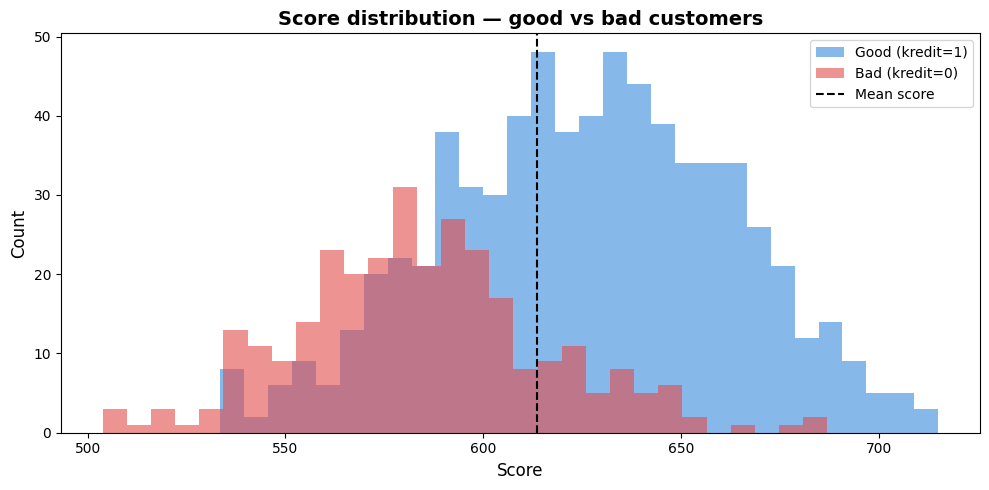

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df[df['kredit'] == 1]['score'], bins=30, alpha=0.6, color='#378ADD', label='Good (kredit=1)')
ax.hist(df[df['kredit'] == 0]['score'], bins=30, alpha=0.6, color='#E24B4A', label='Bad (kredit=0)')
ax.axvline(df['score'].mean(), color='black', linestyle='--', label='Mean score')
ax.set_xlabel('Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Score distribution — good vs bad customers', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/score_distribution.png', dpi=150)
plt.show()

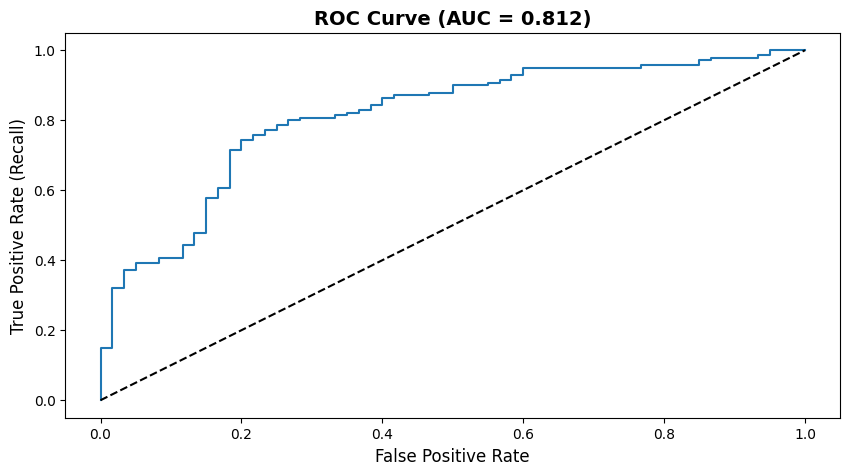

In [20]:
#Probabilities of the model
y_prob= model.predict_proba(X_test_f)[:, 1]


# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


#Plot
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--') #Random Classifier line
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})', fontsize=14, fontweight='bold')
plt.savefig('../outputs/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.5 Conclusions


The presented Scorecard Model provides an integer score to new applicants 
considering financial and demographic variables, ranking them based on risk 
of default. The score goes from 504–715 and customers with a higher score 
represent less risk — the bank can use this to support credit approval decisions.

The model achieves an AUC of 0.8115 with a mean score of 613, meaning most 
customers present an acceptable risk of default. The separation between good 
and bad customers is clear as the Kolmogorov-Smirnov (p<0.05) and Gini (0.62) 
metrics show strong differentiation.

Finally, the main limitations are: the sample has a limited number of 
observations and outdated information corresponding to the 1990s, which may 
impact predictability power. Also, the recall of 0.47 on bad customers can 
be considered low.